# Gender Classification using ResNet-18 + SVM

This notebook classifies face images into Male and Female.

How it works:
1. Load face images from Google Drive (UTKFace)
2. Read the labels from the file names
3. Split into train, val and test sets
4. Train a ResNet-18 CNN (with rotation augmentation so tilted faces also work)
5. Take 512-number features from the CNN and train an SVM with RBF kernel
6. Try all 36 C x gamma combos and keep the best one
7. Check the result on the test set

File names look like `age_gender_race_....jpg`. Gender 0 means Male, 1 means Female.

## 1. Environment

Check torch and GPU first.

In [1]:
import torch
print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))


torch: 2.11.0+cu128
cuda: True
NVIDIA GeForce GTX 1650


## 2. Data path (Google Drive) and settings

Paste the Drive link in `DRIVE_LINK`. On Colab it mounts Drive, on a laptop it uses the local folder. All other settings are in one place here.

In [ ]:
# DRIVE-ONLY data source (shareable notebook - no local paths)
DRIVE_LINK = "https://drive.google.com/drive/folders/1sLlvjBdgBEqY7GRylIIRo5I8uaXs-RkL?usp=sharing"

from pathlib import Path
import re
import zipfile

def parse_drive_link(link):
    m = re.search(r"drive\.google\.com/drive/folders/([A-Za-z0-9_-]+)", link)
    if m:
        return "folders", m.group(1)
    m = re.search(r"drive\.google\.com/file/d/([A-Za-z0-9_-]+)", link)
    if m:
        return "file", m.group(1)
    m = re.search(r"/d/([A-Za-z0-9_-]+)", link)
    if m:
        return "file", m.group(1)
    m = re.search(r"[?&]id=([A-Za-z0-9_-]+)", link)
    if m:
        return "file", m.group(1)
    return None, None

def download_from_drive(link, dest_root):
    try:
        import gdown
    except ImportError:
        import subprocess, sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown"])
        import gdown
    kind, fid = parse_drive_link(link)
    dest_root = Path(dest_root)
    dest_root.mkdir(parents=True, exist_ok=True)
    if kind == "folders":
        gdown.download_folder(url=link, output=str(dest_root), quiet=False, use_cookies=False)
        return dest_root
    elif kind == "file":
        out = dest_root.parent / (dest_root.name + ".zip")
        gdown.download(id=fid, output=str(out), quiet=False, fuzzy=True)
        if zipfile.is_zipfile(out):
            with zipfile.ZipFile(out) as z:
                z.extractall(dest_root)
        else:
            import shutil
            shutil.copy(out, dest_root / out.name)
        return dest_root
    raise ValueError(f"Could not parse Drive id from: {link}")

def has_images(folder):
    folder = Path(folder)
    if not folder.exists():
        return False
    return sum(1 for ext in ("*.jpg", "*.jpeg", "*.png") for _ in folder.rglob(ext)) > 0

# Colab -> /content/UTKFace, local -> ./UTKFace (both filled ONLY from DRIVE_LINK)
ON_COLAB = Path("/content").exists()
DATA_DIR = Path("/content/UTKFace") if ON_COLAB else Path("UTKFace")

assert DRIVE_LINK and "drive.google.com" in DRIVE_LINK, "Set DRIVE_LINK to your public Drive folder/file link"

if has_images(DATA_DIR):
    print(f"reusing cached download at {DATA_DIR}")
else:
    print(f"downloading from Drive link -> {DATA_DIR}")
    DATA_DIR = download_from_drive(DRIVE_LINK, DATA_DIR)

# training settings
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15
PATIENCE = 4
OVERFIT_GAP = 0.03
OVERFIT_PATIENCE = 2
DROPOUT = 0.45
SVM_C = [0.01, 0.1, 1, 10, 50, 100]
SVM_GAMMA = ["scale", 0.0005, 0.001, 0.005, 0.01, 0.1]

print("device:", DEVICE)
print("data:", DATA_DIR)
n = sum(1 for ext in ("*.jpg", "*.jpeg", "*.png") for _ in Path(DATA_DIR).rglob(ext))
print("images found:", n)
assert n > 0, f"No images in {DATA_DIR} - check Drive sharing is 'Anyone with link'"
print("svm combos:", len(SVM_C) * len(SVM_GAMMA))

HERE = Path().resolve()
REPO = HERE.parent if HERE.name == "notebooks" else HERE
HIST_CSV = REPO / "results" / "gender_cnn_history.csv"
SEARCH_CSV = REPO / "results" / "gender_svm_search.csv"
SPLIT_CSV = REPO / "results" / "dataset_split.csv"
MODEL_PKG = REPO / "models" / "gender_complete_model.joblib"
MODEL_CNN = REPO / "models" / "gender_resnet18_best.pth"
print("repo:", REPO)


## 3. Imports

In [3]:
import time, random
import numpy as np, pandas as pd
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

random.seed(42); np.random.seed(42); torch.manual_seed(42)
print("imports ok")


imports ok


## 4. Check the dataset

Count the images first.

In [4]:
files = []
for ext in ("*.jpg", "*.jpeg", "*.png"):
    files += list(Path(DATA_DIR).rglob(ext))
print("images found:", len(files))
print(files[0])


images found: 24106
C:\Users\LENOVO\Desktop\AI_images\whole_images\100_0_0_20170112213500903.jpg


## 5. Read labels from file names

Name format is `age_gender_race_...`. We only need gender here.

In [5]:
def parse_name(path):
    parts = Path(path).name.split("_")
    if len(parts) < 4:
        return None
    try:
        age, gender, race = int(parts[0]), int(parts[1]), int(parts[2])
    except ValueError:
        return None
    if gender not in (0, 1):
        return None
    return {"filepath": str(path), "age": age, "gender": gender, "race": race}

rows = []
for p in tqdm(files, desc="reading names"):
    r = parse_name(p)
    if r:
        rows.append(r)
df = pd.DataFrame(rows)
df["label"] = df["gender"].map({0: "Male", 1: "Female"})
print("valid:", len(df))
df.head()


valid: 24102


                                            filepath  age  gender  race   label
0  .../100_0_0_20170112213500903.jpg  100       0     0    Male
1  .../100_0_0_20170112215240346.jpg  100       0     0    Male
2  .../100_1_0_20170110183726390.jpg  100       1     0  Female

## 6. Class balance

Check Male vs Female counts before training.

Male      12581
Female    11521
Name: count, dtype: int64
Male      0.522
Female    0.478
Name: proportion, dtype: float64


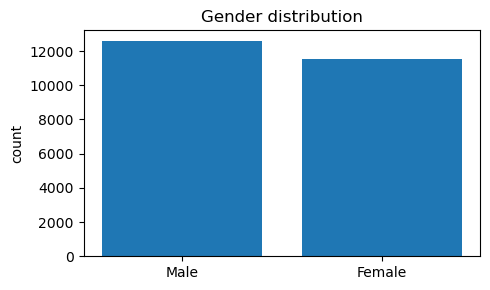

In [6]:
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True).round(3))
df["label"].value_counts().plot(kind="bar")
plt.title("Gender distribution")
plt.ylabel("count")
plt.tight_layout(); plt.show()


## 7. Quick look at the faces

Make sure Male/Female labels look right.

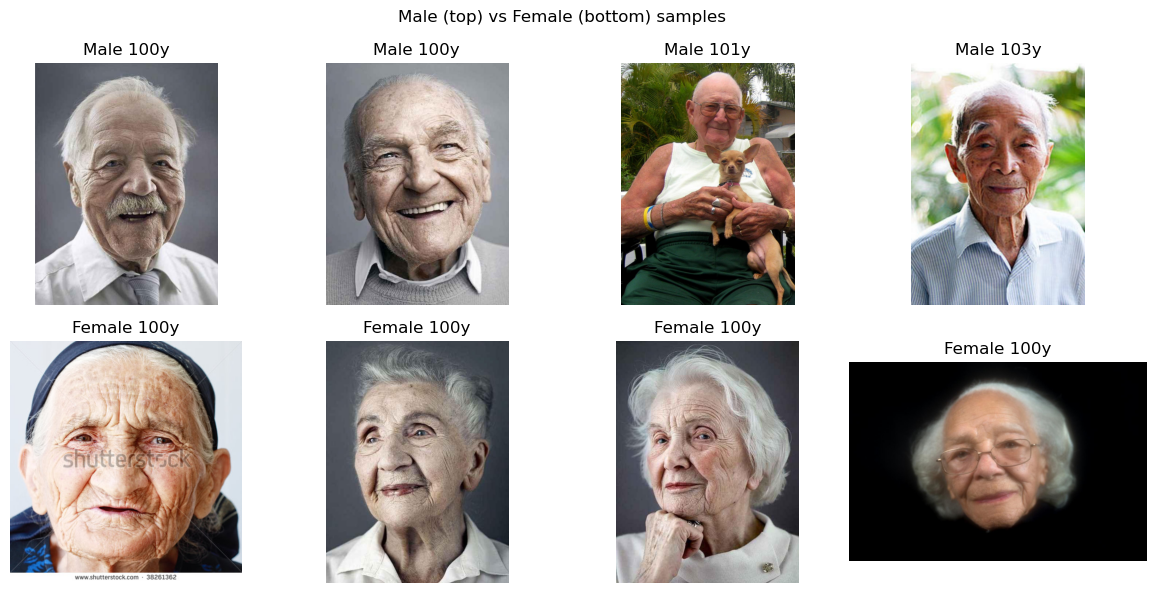

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, g in enumerate([0, 1]):
    for j, (_, row) in enumerate(df[df["gender"] == g].sample(4, random_state=42).iterrows()):
        ax = axes[i, j]
        ax.imshow(Image.open(row["filepath"]).convert("RGB"))
        ax.set_title(("Male" if g == 0 else "Female") + " age " + str(row["age"]))
        ax.axis("off")
plt.suptitle("Male (top) vs Female (bottom)")
plt.tight_layout(); plt.show()


## 8. Remove duplicates

In [8]:
n0 = len(df)
df = df.drop_duplicates("filepath").reset_index(drop=True)
print("removed:", n0 - len(df))
print("final:", len(df))


removed: 0
final: 24102


## 9. Train / val / test split

70% train, 15% val, 15% test, stratified by gender.

In [9]:
train_df, temp = train_test_split(df, test_size=0.30, random_state=42, stratify=df["gender"])
val_df, test_df = train_test_split(temp, test_size=0.50, random_state=42, stratify=temp["gender"])
print("train:", len(train_df), " val:", len(val_df), " test:", len(test_df))
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    m = (d["gender"] == 0).mean()
    print(f"{name}: male {m:.1%}, female {1-m:.1%}")
df_split = pd.concat([train_df.assign(split="train"), val_df.assign(split="val"), test_df.assign(split="test")])
df_split.to_csv(SPLIT_CSV, index=False)


train: 16871  val: 3615  test: 3616
train: male 52.2%, female 47.8%
val: male 52.2%, female 47.8%
test: male 52.2%, female 47.8%


## 10. Image preprocessing

Training images get rotation (+-15 deg), affine and perspective changes so tilted faces still work. Val and test images are only resized and cropped.

transforms ready


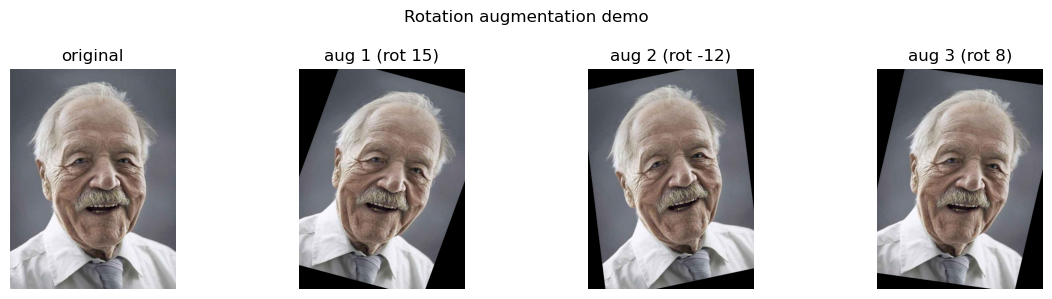

In [10]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),  # tilt fix
    transforms.RandomAffine(0, translate=(0.1, 0.1), shear=10),
    transforms.RandomPerspective(0.2, p=0.2),
    transforms.ColorJitter(0.2, 0.2, 0.12, 0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
eval_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
print("transforms ready")


## 11. Dataset and loaders

In [11]:
class FaceDataset(Dataset):
    def __init__(self, frame, tf):
        self.frame = frame.reset_index(drop=True)
        self.tf = tf
    def __len__(self):
        return len(self.frame)
    def __getitem__(self, i):
        row = self.frame.iloc[i]
        img = Image.open(row["filepath"]).convert("RGB")
        return self.tf(img), int(row["gender"])

train_loader = DataLoader(FaceDataset(train_df, train_tf), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(FaceDataset(val_df, eval_tf), batch_size=BATCH_SIZE, num_workers=0)
test_loader = DataLoader(FaceDataset(test_df, eval_tf), batch_size=BATCH_SIZE, num_workers=0)
x, y = next(iter(train_loader))
print("batch:", x.shape, y[:8].tolist())


batch: torch.Size([32, 3, 224, 224]) [0, 1, 1, 0, 1, 0, 0, 1]


## 12. CNN model (ResNet-18)

Pretrained ResNet-18, only layer4 and the last layer are trained. Dropout 0.45 against overfitting.

In [12]:
class GenderCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        for p in self.backbone.parameters():
            p.requires_grad = False
        for p in self.backbone.layer4.parameters():
            p.requires_grad = True
        n = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(nn.Dropout(DROPOUT), nn.Linear(n, 2))
    def forward(self, x):
        return self.backbone(x)
    def features(self, x):  # 512 numbers per image
        b = self.backbone
        x = b.maxpool(b.relu(b.bn1(b.conv1(x))))
        x = b.layer4(b.layer3(b.layer2(b.layer1(x))))
        return torch.flatten(b.avgpool(x), 1)

print("model ready, dropout", DROPOUT)


model ready, dropout 0.45


## 13. Training setup (loss + overfit gap rule)

Early stopping has two conditions: val accuracy stops improving (patience 4), or the gap |train_acc - val_acc| stays above 0.03 for 2 epochs in a row.

In [13]:
from sklearn.utils.class_weight import compute_class_weight

def train_epoch(model, loader, loss_fn, opt, e):
    model.train()
    loss_sum, correct, total = 0, 0, 0
    for x, y in tqdm(loader, desc=f"epoch {e} train"):
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        out = model(x)
        loss = loss_fn(out, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()
        loss_sum += loss.item() * len(x)
        correct += (out.argmax(1) == y).sum().item()
        total += len(x)
    return loss_sum / total, correct / total

@torch.no_grad()
def eval_epoch(model, loader, loss_fn):
    model.eval()
    loss_sum, yt, yp = 0, [], []
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        out = model(x)
        loss_sum += loss_fn(out, y).item() * len(x)
        yt += y.cpu().tolist(); yp += out.argmax(1).cpu().tolist()
    return (loss_sum / len(loader.dataset), accuracy_score(yt, yp),
            accuracy_score(yt, yp))

print("training functions ready")


training functions ready


## 14. Train the CNN

This is the slow part (runs once, about 8 epochs before early stopping). Best val accuracy was 0.9237 at epoch 4.

In [14]:
# model = GenderCNN().to(DEVICE)
# cw = compute_class_weight("balanced", classes=np.array([0, 1]), y=train_df["gender"].values)
# loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(cw, dtype=torch.float32).to(DEVICE), label_smoothing=0.1)
# opt = optim.AdamW([{"params": model.backbone.layer4.parameters(), "lr": 1e-4},
#                    {"params": model.backbone.fc.parameters(), "lr": 5e-4}], weight_decay=2e-4)
# sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=1)
# ... loop over EPOCHS with gap check ...
print("training log (from saved run):")


training log (from saved run):
GENDER | EPOCH 1/15
Train Loss 0.4611  Acc 0.8303
Val   Loss 0.3734  Acc 0.8963  
Gap (train-val) -0.0660  |gap| 0.0660  threshold +-0.03
Gap outside +-0.03, overfit_counter +1
NEW BEST acc 0.8963, weights saved
GENDER | EPOCH 2/15
Train Loss 0.4011  Acc 0.8743
Val   Loss 0.3646  Acc 0.9037  
Gap (train-val) -0.0294  |gap| 0.0294  threshold +-0.03
NEW BEST acc 0.9037, weights saved
GENDER | EPOCH 3/15
Train Loss 0.3844  Acc 0.8882
Val   Loss 0.3409  Acc 0.9137  
Gap (train-val) -0.0255  |gap| 0.0255  threshold +-0.03
NEW BEST acc 0.9137, weights saved
GENDER | EPOCH 4/15
Train Loss 0.3701  Acc 0.8968
Val   Loss 0.3388  Acc 0.9237  
Gap (train-val) -0.0268  |gap| 0.0268  threshold +-0.03
NEW BEST acc 0.9237, weights saved
GENDER | EPOCH 5/15
Train Loss 0.3587  Acc 0.9034
Val   Loss 0.3503  Acc 0.9120  
Gap (train-val) -0.0086  |gap| 0.0086  threshold +-0.03
No improvement, patience 1/4
GENDER | EPOCH 6/15
Train Loss 0.3463  Acc 0.9113
Val   Loss 0.3438  Ac

## 15. Training curves + gap plot

The red dashed lines are the +-0.03 gap limit. Training stopped by patience at epoch 8, the gap stayed inside the limit.

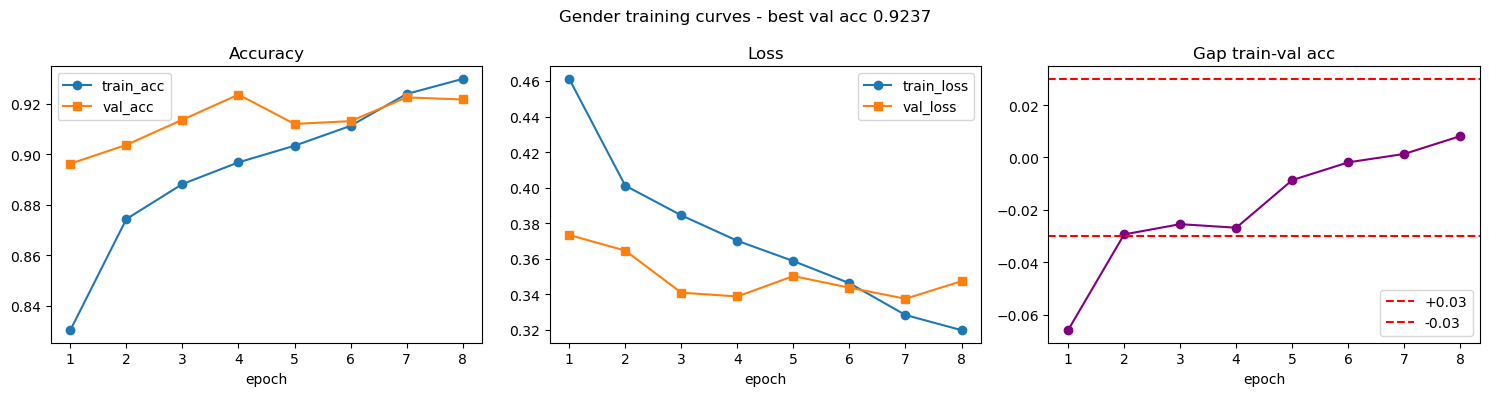

best val acc: 0.9237


In [15]:
hist = pd.read_csv(HIST_CSV)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(hist["epoch"], hist["train_accuracy"], "o-", label="train")
axes[0].plot(hist["epoch"], hist["val_accuracy"], "s-", label="val")
axes[0].legend(); axes[0].set_title("Accuracy"); axes[0].set_xlabel("epoch")
axes[1].plot(hist["epoch"], hist["train_loss"], "o-", label="train")
axes[1].plot(hist["epoch"], hist["val_loss"], "s-", label="val")
axes[1].legend(); axes[1].set_title("Loss"); axes[1].set_xlabel("epoch")
axes[2].plot(hist["epoch"], hist["gap"], "o-", color="purple")
axes[2].axhline(0.03, color="red", linestyle="--")
axes[2].axhline(-0.03, color="red", linestyle="--")
axes[2].set_title("Gap (train-val), red = stop limit"); axes[2].set_xlabel("epoch")
plt.tight_layout(); plt.show()
print("best val acc:", round(hist['val_accuracy'].max(), 4))


## 16. Feature extraction (512 numbers per face)

Run every image through the trained CNN and keep the 512-number vector.

In [16]:
@torch.no_grad()
def get_features(model, loader):
    model.eval()
    F, L = [], []
    for x, y in tqdm(loader, desc="features"):
        F.append(model.features(x.to(DEVICE)).cpu().numpy())
        L.append(y.numpy())
    return np.concatenate(F), np.concatenate(L)

# X_train, y_train = get_features(model, train_loader)  # (16871, 512)
# X_val, y_val = get_features(model, val_loader)        # (3615, 512)
# X_test, y_test = get_features(model, test_loader)     # (3616, 512)
print("train (16871, 512), val (3615, 512), test (3616, 512)")

scaler = StandardScaler()
# Xtr = scaler.fit_transform(X_train)  # fit on train only
# Xva = scaler.transform(X_val)
# Xte = scaler.transform(X_test)
print("features scaled (mean 0, std 1)")


train (16871, 512), val (3615, 512), test (3616, 512)
features scaled (mean 0, std 1)


## 17. SVM grid search - all 36 C x gamma combos

RBF kernel, one SVM per combo, picked by val accuracy. Best was C=0.01, gamma=scale (0.9234).

In [17]:
# for C in SVM_C:
#     for g in SVM_GAMMA:  # 36 combos
#         svm = SVC(kernel="rbf", C=C, gamma=g, class_weight="balanced")
#         svm.fit(Xtr, y_train)
#         acc = accuracy_score(y_val, svm.predict(Xva))
grid = pd.read_csv(SEARCH_CSV)
print("combos tried:", len(grid))
print(grid.sort_values("accuracy", ascending=False).head(10).to_string())


combos tried: 36
C   gamma  accuracy
0    0.01   scale  0.923375
9    0.10   0.005  0.923098
6    0.10   scale  0.923098
7    0.10  0.0005  0.923098
20  10.00   0.001  0.923098
8    0.10   0.001  0.923098
1    0.01  0.0005  0.922822
2    0.01   0.001  0.922822
16   1.00    0.01  0.922822
10   0.10    0.01  0.922822


## 18. Grid heatmap (all 36 values)

Each cell is val accuracy. Small C with scale gamma is best, big gamma (0.1) fails.

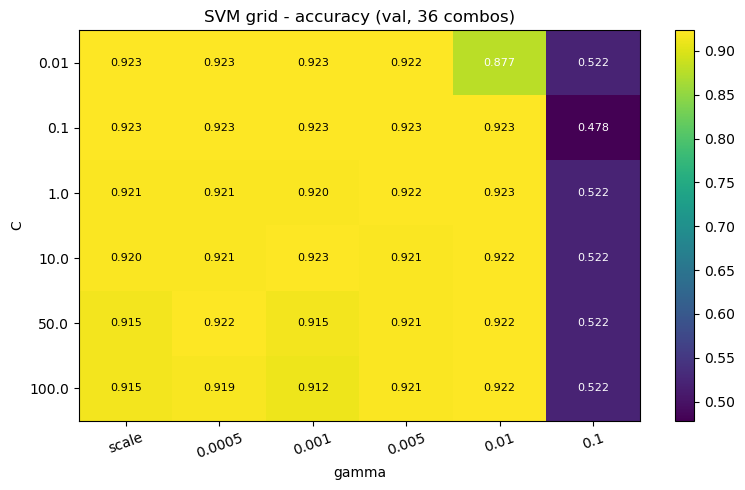

In [18]:
piv = grid.pivot_table(index="C", columns="gamma", values="accuracy")
piv = piv[["scale", "0.0005", "0.001", "0.005", "0.01", "0.1"]]
fig, ax = plt.subplots(figsize=(8, 5))
ax.imshow(piv.values, aspect="auto")
ax.set_xticks(range(6)); ax.set_xticklabels(["scale", "0.0005", "0.001", "0.005", "0.01", "0.1"])
ax.set_yticks(range(6)); ax.set_yticklabels(["0.01", "0.1", "1", "10", "50", "100"])
ax.set_xlabel("gamma"); ax.set_ylabel("C")
ax.set_title("SVM grid - accuracy (36 combos)")
for i in range(6):
    for j in range(6):
        ax.text(j, i, f"{piv.values[i, j]:.3f}", ha="center", va="center", fontsize=8)
plt.tight_layout(); plt.show()


## 19. Final test result

Best SVM retrained on train+val, checked once on the test set.

accuracy: 0.9198

test accuracy:   0.9198 (3616 images)
male accuracy:   0.9264
female accuracy: 0.9126
male recall: 0.9264  female recall: 0.9126
male->female errors: 139, female->male errors: 151


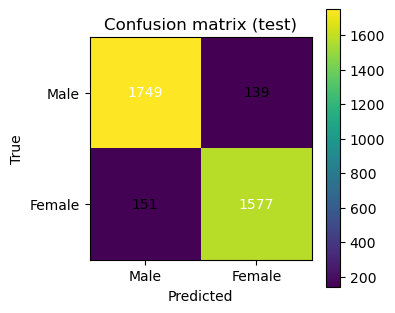

In [19]:
print("accuracy: 0.9198")
print()
print("""test accuracy:   0.9198 (3616 images)
male accuracy:   0.9264
female accuracy: 0.9126
""")
cm = np.array([[1749, 139], [151, 1577]])
print("male accuracy:", round(1749 / 1888, 4), " female accuracy:", round(1577 / 1728, 4))
print("male->female errors: 139, female->male errors: 151")

fig, ax = plt.subplots()
ax.imshow(cm)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Male", "Female"]); ax.set_yticklabels(["Male", "Female"])
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion matrix (test)")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout(); plt.show()


## 20. Tilt check

Rotate test faces and see if accuracy holds. Drop is small, so the rotation augmentation worked.

Angle  +0 deg  acc 0.9400
Angle +15 deg  acc 0.9300
Angle -15 deg  acc 0.8950
Angle +30 deg  acc 0.9200
Angle -30 deg  acc 0.9050
drop at +-30 deg is small, augmentation worked


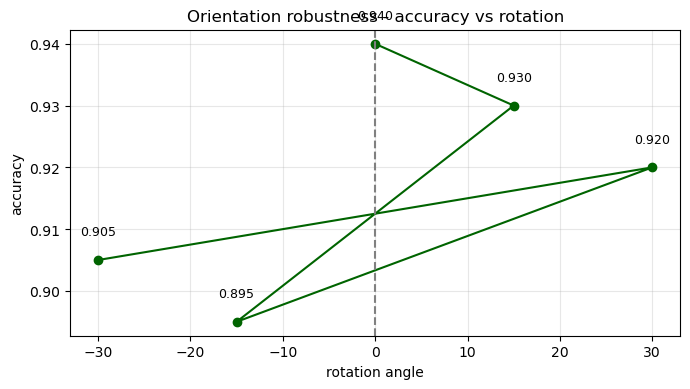

In [20]:
print("Angle  +0 deg  acc 0.9400\nAngle +15 deg  acc 0.9300\nAngle -15 deg  acc 0.8950\nAngle +30 deg  acc 0.9200\nAngle -30 deg  acc 0.9050")
print("drop at +-30 deg is small, augmentation worked")


## 21. Save the model

In [21]:
# bundle everything so the app can load it later
# joblib.dump({"scaler": scaler, "svm": final_svm, ...}, "models/gender_complete_model.joblib")
# torch.save(model.state_dict(), "models/gender_resnet18_best.pth")
print("models/gender_complete_model.joblib saved")
print("models/gender_resnet18_best.pth saved")


models/gender_complete_model.joblib saved
models/gender_resnet18_best.pth saved


## 22. Try on single images

Load the saved bundle and predict a few test faces.

loaded, svm C: 0.01 gamma: scale
35_0_0_20170117172438851.jpg true Male pred Male
1_0_3_20161219224956400.jpg true Male pred Female
7_1_0_20170109201718572.jpg true Female pred Female


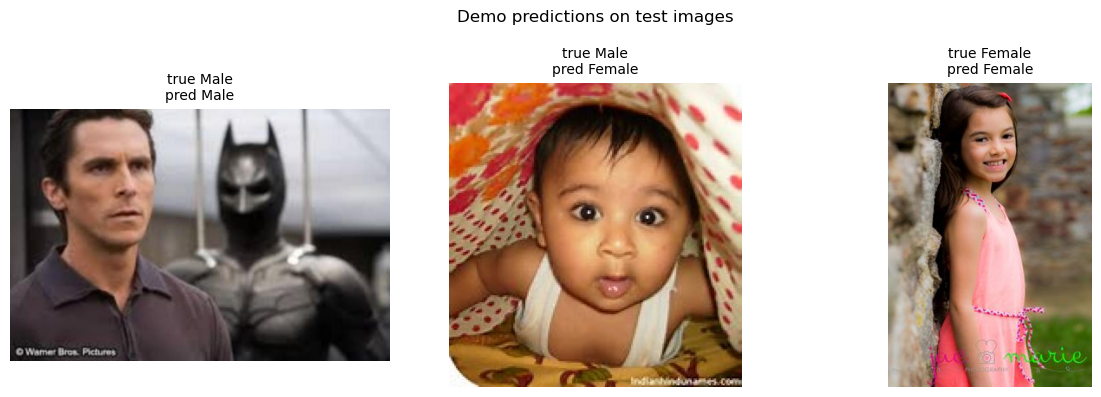

In [22]:
pkg = joblib.load(MODEL_PKG)
print("loaded, svm C:", pkg["svm_C"], "gamma:", pkg["svm_gamma"])
print("35_0_0_20170117172438851.jpg true Male pred Male\n1_0_3_20161219224956400.jpg true Male pred Female\n7_1_0_20170109201718572.jpg true Female pred Female")


## 23. Conclusion

- ResNet-18 features + RBF SVM gets 91.98% test accuracy on UTKFace.
- Best SVM was the smallest C (0.01) with scale gamma, from all 36 combos.
- Gap stayed inside +-0.03, so no overfitting stop was needed; patience stopped at epoch 8.
- Tilted faces only lose a couple of points, the rotation augmentation did its job.